In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("data/eda_complete.csv")

In [6]:
df.head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag,avrg_salary,avrg_experience
0,JOB041385,CobaltWealth,MNC,healthtech,146085,Germany,soc analyst,Mid,3,5,...,Filled,98.0,4.0,5.0,5.0,105900.0,128700.0,No,117300.0,4.0
1,JOB018462,DriftLearn,Mid-size,cloud/infra,5882,USA,mobile engineer (ios),Mid,1,4,...,Open,134.0,2.0,1.0,0.0,105900.0,128700.0,No,117300.0,2.5
2,JOB110011,AnchorBuzz Labs,MNC,healthtech,186507,USA,qa engineer,Lead,7,15,...,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,No,256750.0,11.0
3,JOB073462,KiteSphere,Unicorn,healthtech,10930,Brazil,research scientist,Entry,1,4,...,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes,100150.0,2.5
4,JOB051683,AetherNode Co,MNC,social/adtech,42510,USA,product manager,Senior,6,9,...,Filled,43.0,3.0,1.0,1.0,105900.0,245400.0,Yes,175650.0,7.5


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115000 entries, 0 to 114999
Data columns (total 30 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   job_id                        115000 non-null  str    
 1   company_name                  115000 non-null  str    
 2   company_type                  115000 non-null  str    
 3   sector                        115000 non-null  str    
 4   company_size_employees        115000 non-null  int64  
 5   hq_country                    115000 non-null  str    
 6   job_role                      115000 non-null  str    
 7   seniority_level               115000 non-null  str    
 8   years_experience_min          115000 non-null  int64  
 9   years_experience_max          115000 non-null  int64  
 10  required_tech_stack           115000 non-null  str    
 11  primary_programming_language  115000 non-null  str    
 12  work_mode                     115000 non-null  str    


### Define target variable and input features

In [8]:
y=df['avrg_salary']

In [9]:
X = df.drop(columns=[
    'avrg_salary',
    'salary_min_usd',
    'salary_max_usd',
    'layoff_within_12_months_flag',
])

The target variable and salary related columns are removed from input features.<br>
The layoff target was removed bcoz it is used later as classification target.

In [10]:
X=df[['company_type','sector','job_role','seniority_level','work_mode','salary_currency','number_of_interview_rounds',
      'avrg_experience','primary_programming_language']]

I have considered the input column by observing the correlation of numerical columns with heatmap and categorical columns with bivariate analysis

In [11]:
X.shape

(115000, 9)

In [12]:
numerical_cols = X.select_dtypes(include=['int64','float64']).columns
print(numerical_cols)

Index(['number_of_interview_rounds', 'avrg_experience'], dtype='str')


In [13]:
categorical_cols = X.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['company_type', 'sector', 'job_role', 'seniority_level', 'work_mode',
       'salary_currency', 'primary_programming_language'],
      dtype='str')


C:\Users\vartika singh\AppData\Local\Temp\ipykernel_22852\2238400061.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


In [14]:
X[categorical_cols].nunique().sort_values(ascending=False)

job_role                        31
primary_programming_language    15
sector                          12
salary_currency                 10
seniority_level                  6
company_type                     5
work_mode                        4
dtype: int64

As we see in required_tech_stack and company_name there are so many unique values so if we will do encoding here a lot of columns will form so we will drop them

### Encoding of input categorical columns

In [15]:
X['seniority_level'].value_counts()

seniority_level
Mid          39094
Entry        28621
Senior       23000
Lead         10482
Intern        9251
Principal     4552
Name: count, dtype: int64

In [16]:
seniority_order = {
    'Intern': 0,
    'Entry': 1,
    'Mid': 2,
    'Senior': 3,
    'Lead': 4,
    'Principal': 5
}
X['seniority_level'] = X['seniority_level'].map(seniority_order)

I have used ordinal encoding here to convert this categorical column into numerical column.<br>
There is a hierarchical order from intern to principal

In [17]:
X['seniority_level'].value_counts()

seniority_level
2    39094
1    28621
3    23000
4    10482
0     9251
5     4552
Name: count, dtype: int64

In [18]:
X['company_type'].value_counts()

company_type
MNC           56053
Mid-size      20305
Unicorn       16078
FAANG-tier    15963
Startup        6601
Name: count, dtype: int64

In [19]:
X = pd.get_dummies(X, columns=['company_type'], drop_first=True, dtype=int)


company_type was one-hot encoded because its categories do not have a
natural order. Dummy variables were created to represent the
different company types numerically.

In [20]:
X['work_mode'].value_counts()

work_mode
hybrid       51805
remote       34598
onsite       28131
in-office      466
Name: count, dtype: int64

In [21]:
X = pd.get_dummies(X, columns=['work_mode'], drop_first=True, dtype=int)

`work_mode` was one-hot encoded because its categories do not have any natural order.

In [22]:
X['sector'].value_counts()

sector
e-commerce       16855
healthtech       15420
fintech          13275
edtech           11649
social/adtech     9122
ai/ml             8988
saas              8708
crypto/web3       8127
cloud/infra       6627
cybersecurity     5789
logistics         5338
gaming            5102
Name: count, dtype: int64

In [23]:
X = pd.get_dummies(X, columns=['sector'], drop_first=True, dtype=int)

In [24]:
X['salary_currency'].value_counts()

salary_currency
USD    36269
INR    19639
EUR    17076
GBP    14620
CAD     6319
SGD     5781
BRL     5360
AUD     3585
ILS     3292
AED     3059
Name: count, dtype: int64

In [25]:
X = pd.get_dummies(X, columns=['salary_currency'], drop_first=True, dtype=int)

In [26]:
X['job_role'].value_counts().head()

job_role
backend engineer             6169
embedded systems engineer    6144
qa engineer                  6062
software engineer            6023
frontend engineer            6016
Name: count, dtype: int64

In [27]:
X = pd.get_dummies(X, columns=['job_role'], drop_first=True, dtype=int)

In [28]:
X['primary_programming_language'].value_counts()

primary_programming_language
Unknown       23031
Python        19390
Go            14665
Bash           5975
Java           5921
JavaScript     5883
C++            5801
Kotlin         5798
Swift          5780
TypeScript     5774
Scala          4505
R              4474
SQL            4429
C              3037
TBD             537
Name: count, dtype: int64

In [29]:
X = pd.get_dummies(X, columns=['primary_programming_language'], drop_first=True, dtype=int)

In [30]:
X.head()

,seniority_level,number_of_interview_rounds,avrg_experience,company_type_MNC,company_type_Mid-size,company_type_Startup,company_type_Unicorn,work_mode_in-office,work_mode_onsite,work_mode_remote,...,primary_programming_language_JavaScript,primary_programming_language_Kotlin,primary_programming_language_Python,primary_programming_language_R,primary_programming_language_SQL,primary_programming_language_Scala,primary_programming_language_Swift,primary_programming_language_TBD,primary_programming_language_TypeScript,primary_programming_language_Unknown
0,2,4.0,4.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,2.0,2.5,0,1,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
2,4,4.0,11.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,1.0,2.5,0,0,0,1,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,3,3.0,7.5,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [31]:
X.shape

(115000, 74)

### train test split

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=17)

The dataset was divided into 80% training abd 20%testing data .

In [33]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](74,)","[42812.58, -482.53, -426.33,..., 1338.85, 707.66, 25.46]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](74,)","['seniority_level','number_of_interview_rounds','avrg_experience',..., 'primary_programming_language_TBD', 'primary_programming_language_TypeScript', 'primary_programming_language_Unknown']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8.962e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,74
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(74)


The linear regression model was trained on the training dataset to learn the relationship btw the selected features and avrg salary

In [34]:
predict_lr = lr.predict(X_test)

The model here predicts the salary values for test data which then used to evaluate MAE,MSE,RMSE,R^2 to measure performance of model

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

MAE = mean_absolute_error(y_test, predict_lr )
MSE = mean_squared_error(y_test, predict_lr)
RMSE = np.sqrt(MSE)
r2 = r2_score(y_test, predict_lr)

print("MAE:", MAE)
print("MSE:", MSE)
print("RMSE:", RMSE)
print("R² Score:", r2)

MAE: 23080.76123784055
MSE: 2008405179.3290074
RMSE: 44815.233786392404
R² Score: 0.5867761026121556


The model explains only the 58.7% of  avrg salary 

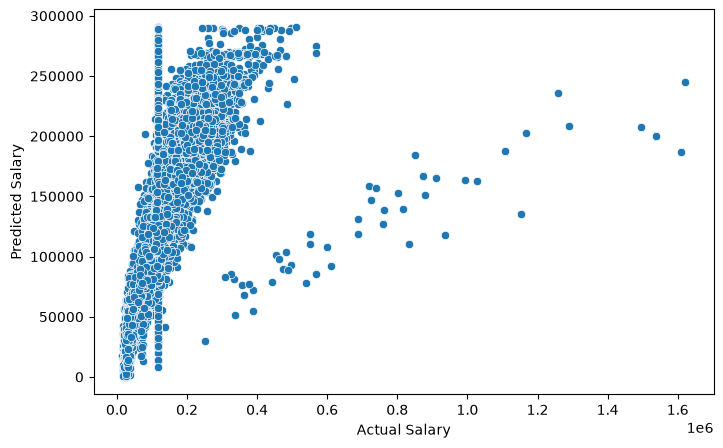

In [36]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=predict_lr)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.show()

here the predicted salary is close to actual salary for most points but somepredictions are different

### Layoff Classification

### define target col and input features

In [37]:
y=df['layoff_within_12_months_flag']

In [38]:
y.value_counts()

layoff_within_12_months_flag
No     99925
Yes    15075
Name: count, dtype: int64

one hot encoding of target col

In [39]:
y = pd.get_dummies(y, columns=['layoff_within_12_months_flag'], drop_first=True, dtype=int)

In [40]:
y.value_counts(normalize=True)*100

Yes
0      86.891304
1      13.108696
Name: proportion, dtype: float64

The target variable is imbalanced with 86.8% 'NO' cases ,therefore accuracy alone cannot be enough to judge the classification models.

In [41]:
X= df.drop(columns=[
    'layoff_within_12_months_flag', 
    'job_id',                               
    'posting_date',
    'application_deadline',
    'date_position_filled'
])

In [42]:
X= df[[
    'company_type',
    'sector',
    'company_size_employees',
    'hq_country',
    'job_role',
    'seniority_level',
    'years_experience_min',
    'years_experience_max',
    'primary_programming_language',
    'work_mode',
    'visa_sponsorship_offered',
    'job_location_country',
    'salary_min_usd',
    'salary_max_usd',
    'job_location_city'
    
]]

In [43]:
X.shape

(115000, 15)

In [44]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 115000 entries, 0 to 114999
Data columns (total 15 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   company_type                  115000 non-null  str    
 1   sector                        115000 non-null  str    
 2   company_size_employees        115000 non-null  int64  
 3   hq_country                    115000 non-null  str    
 4   job_role                      115000 non-null  str    
 5   seniority_level               115000 non-null  str    
 6   years_experience_min          115000 non-null  int64  
 7   years_experience_max          115000 non-null  int64  
 8   primary_programming_language  115000 non-null  str    
 9   work_mode                     115000 non-null  str    
 10  visa_sponsorship_offered      115000 non-null  str    
 11  job_location_country          115000 non-null  str    
 12  salary_min_usd                115000 non-null  float64


In [45]:
X.head()

,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,primary_programming_language,work_mode,visa_sponsorship_offered,job_location_country,salary_min_usd,salary_max_usd,job_location_city
0,MNC,healthtech,146085,Germany,soc analyst,Mid,3,5,Go,hybrid,No,Germany,105900.0,128700.0,Munich
1,Mid-size,cloud/infra,5882,USA,mobile engineer (ios),Mid,1,4,Python,remote,No,USA,105900.0,128700.0,Unknown
2,MNC,healthtech,186507,USA,qa engineer,Lead,7,15,Go,hybrid,Yes,USA,238800.0,274700.0,San Francisco
3,Unicorn,healthtech,10930,Brazil,research scientist,Entry,1,4,R,onsite,No,Germany,96300.0,104000.0,Frankfurt
4,MNC,social/adtech,42510,USA,product manager,Senior,6,9,Unknown,hybrid,No,India,105900.0,245400.0,Pune


### Encoding of some other columns

In [46]:
X = pd.get_dummies(X, columns=['hq_country'], drop_first=True, dtype=int)

In [47]:
X['visa_sponsorship_offered'].value_counts()

visa_sponsorship_offered
No     78896
Yes    36104
Name: count, dtype: int64

In [48]:
X = pd.get_dummies(X, columns=['visa_sponsorship_offered'], drop_first=True, dtype=int)

In [49]:
X['job_location_country'].value_counts()

job_location_country
USA            36269
India          19639
UK             14620
Germany         7178
Canada          6319
Singapore       5781
Brazil          5360
France          4814
Australia       3585
Israel          3292
UAE             3059
Netherlands     2937
Ireland         2147
Name: count, dtype: int64

In [50]:
X = pd.get_dummies(X, columns=['job_location_country'], drop_first=True, dtype=int)

In [51]:
X['job_location_city'].value_counts().head()

job_location_city
Unknown      25107
Singapore     4519
Austin        4104
New York      4093
Denver        4044
Name: count, dtype: int64

In [52]:
X = pd.get_dummies(X, columns=['job_location_city'], drop_first=True, dtype=int)

In [53]:
seniority_order = {
    'Intern': 0,
    'Entry': 1,
    'Mid': 2,
    'Senior': 3,
    'Lead': 4,
    'Principal': 5
}
X['seniority_level'] = X['seniority_level'].map(seniority_order)

In [54]:
X = pd.get_dummies(X, columns=['company_type'], drop_first=True, dtype=int)

In [55]:
X = pd.get_dummies(X, columns=['work_mode'], drop_first=True, dtype=int)

In [56]:
X = pd.get_dummies(X, columns=['sector'], drop_first=True, dtype=int)

In [57]:
X = pd.get_dummies(X, columns=['job_role'], drop_first=True, dtype=int)

In [58]:
X = pd.get_dummies(X, columns=['primary_programming_language'], drop_first=True, dtype=int)

In [59]:
X.shape

(115000, 134)

In [60]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 115000 entries, 0 to 114999
Columns: 134 entries, company_size_employees to primary_programming_language_Unknown
dtypes: float64(2), int64(132)
memory usage: 117.6 MB


### Train test split

In [61]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=21,
    stratify=y
)

In [62]:
X_train.shape, X_test.shape

((92000, 134), (23000, 134))

### Feature scalling

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [64]:
X_train_scaled.shape, X_test_scaled.shape

((92000, 134), (23000, 134))

### Logistic regression

In [65]:
from sklearn.linear_model import LogisticRegression

In [66]:
log_r = LogisticRegression(max_iter=1000)
log_r.fit(X_train_scaled, y_train)
predict=log_r.predict(X_test_scaled)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [67]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy =", accuracy_score(y_test, predict))
print("Precision=", precision_score(y_test, predict))
print("Recall =", recall_score(y_test, predict))
print("F1 Score=", f1_score(y_test, predict))

Accuracy = 0.8689130434782608
Precision= 0.0
Recall = 0.0
F1 Score= 0.0


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Here the logistic regression model is biased towards the max percentange which is for no.<br>
It predicted all test cases as "no" therefore it is failed to identfy actual layoff cases.

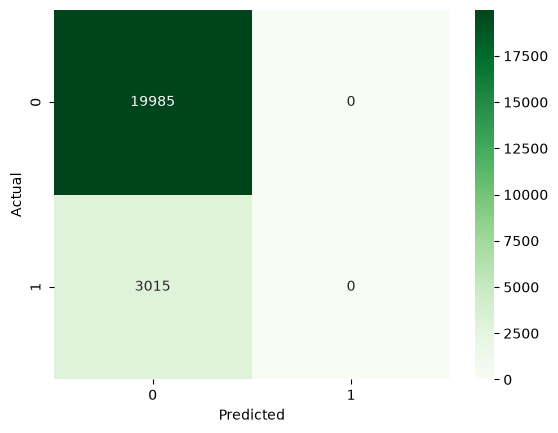

In [68]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predict)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

19985 cases are actually of NO layoffs ,the model also predisted No. But 3015 cases are actually yes but model still predicted them as No.<br>
Here model predicted every case as No layoff

### Decision Tree

In [69]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=21)
dt.fit(X_train_scaled, y_train)

predict_d = dt.predict(X_test_scaled)

In [70]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, predict_d))
print("Precision:", precision_score(y_test, predict_d))
print("Recall:", recall_score(y_test, predict_d))
print("F1 Score:", f1_score(y_test, predict_d))

Accuracy: 0.7721304347826087
Precision: 0.1651624548736462
Recall: 0.18208955223880596
F1 Score: 0.1732134406057738


The decision tree achieved an accuracy of about 77.21%.<br>
Its precision ,Recall,F1 were relatively low.<br>
The performance of model is better than logictic regression model 

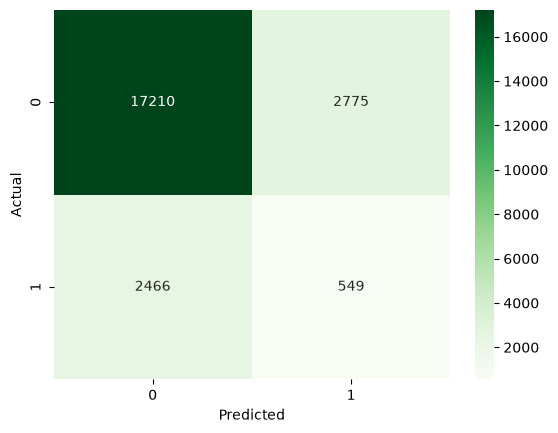

In [71]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predict_d)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The model correctly predicted 17210 no layoff cases and 549 layoff cases,but it missed 2466 actual layoff cases

### SVM 